TASK-01

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 547 (2.14 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.3131 - loss: 1.4925 - val_accuracy: 0.2593 - val_loss: 1.3531
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3044 - loss: 1.3850 - val_accuracy: 0.2593 - val_loss: 1.2266
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3464 - loss: 1.2432 - val_accuracy: 0.2963 - val_loss: 1.1131
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4140 - loss: 1.0840 - val_accuracy: 0.3333 - val_loss: 1.0118
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4336 - loss: 1.0041 - val_accuracy: 0.4815 - val_loss: 0.9192
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4723 - loss: 0.9473 - val_accuracy: 0.5185 - val_loss: 0.8349
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4744 - loss: 0.8681 - val_accuracy: 0.5926 - val_loss: 0.7595
Epoch 8/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5582 - loss: 0.7675 - val_accuracy: 0.6667 - val_loss:

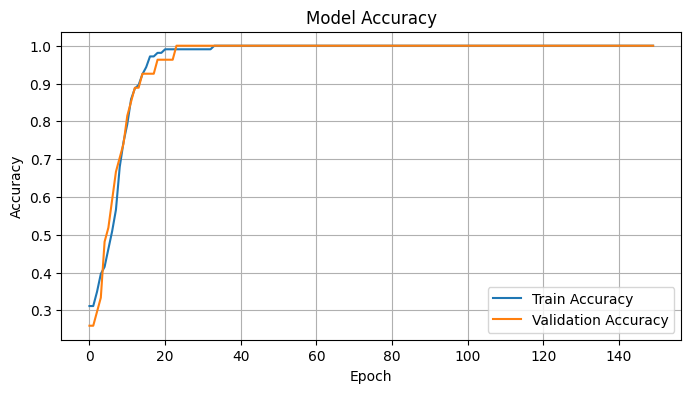

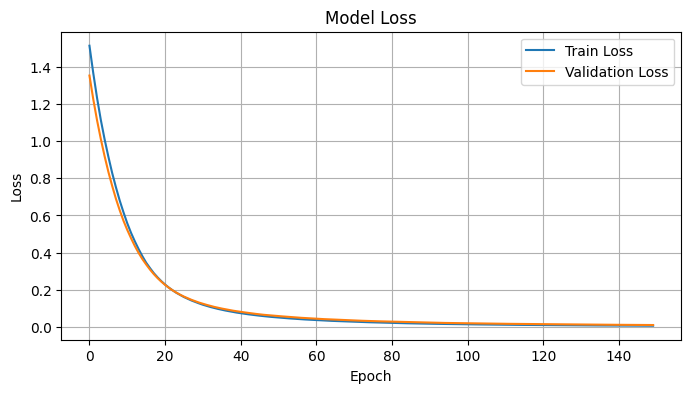

In [ ]:
wine = load_wine()
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

y_train_oh = to_categorical(y_train, num_classes=3)
y_test_oh = to_categorical(y_test, num_classes=3)

model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_s.shape[1],)),
    Dense(3, activation="softmax")
])

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

history = model.fit(
    X_train_s,
    y_train_oh,
    epochs=150,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test_s, y_test_oh, verbose=0)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


TASK-02

In [ ]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, Flatten, Dense
from tensorflow.keras.metrics import AUC

from sklearn.metrics import roc_curve, roc_auc_score

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 300, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 19200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │       614,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,254,465 (4.79 MB)

 Trainable params: 1,254,465 (4.79 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
167/167 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.6085 - auc: 0.6642 - loss: 0.6227 - val_accuracy: 0.8619 - val_auc: 0.9367 - val_loss: 0.3233
Epoch 2/12
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9331 - auc: 0.9799 - loss: 0.1857 - val_accuracy: 0.8653 - val_auc: 0.9438 - val_loss: 0.3276
Epoch 3/12
167/167 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.9920 - auc: 0.9993 - loss: 0.0449 - val_accuracy: 0.8597 - val_auc: 0.9412 - val_loss: 0.3933
Epoch 4/12
167/167 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9994 - auc: 1.0000 - loss: 0.0124 - val_accuracy: 0.8677 - val_auc: 0.9397 - val_loss: 0.3915
Epoch 5/12
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.9999 - auc: 1.0000 - loss: 0.0041 - val_accuracy: 0.8683 - val_auc: 0.9390 - val_loss: 0.4183
Epoch 6/12
167/167 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0021 - val_accuracy: 0.8563 - val_auc: 0.9311 - val_loss: 0.4886
Epoch 7/12
167/167 ━━━━━━━━━━━━━━

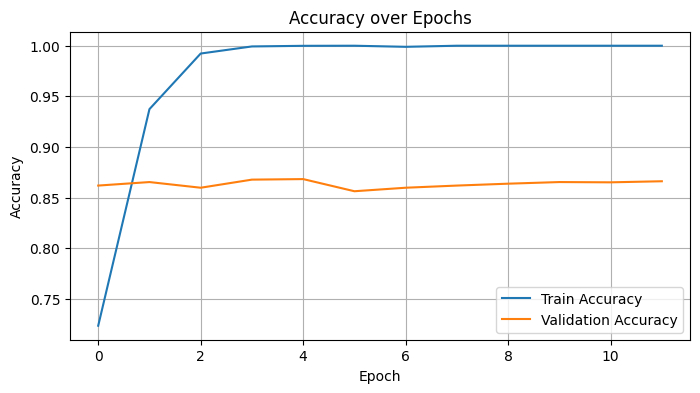

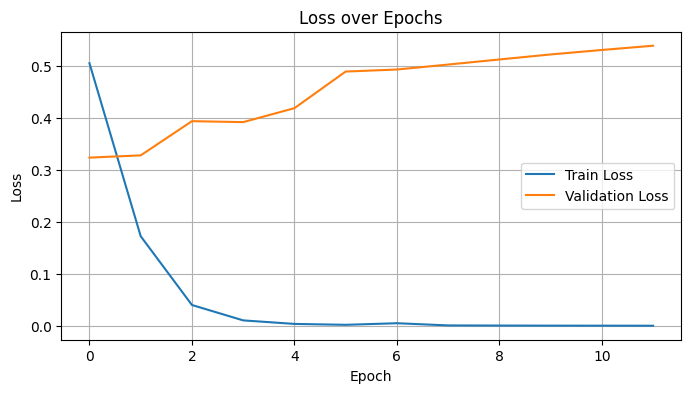

ROC AUC (sklearn): 0.9376


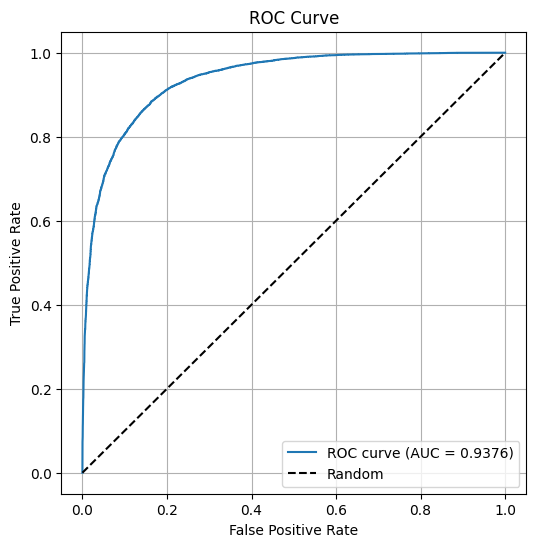

In [ ]:
num_words = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

maxlen = 300
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

n_train = int(0.85 * len(x_train))
x_train_part = x_train[:n_train]
y_train_part = y_train[:n_train]
x_val = x_train[n_train:]
y_val = y_train[n_train:]

model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=maxlen),
    Flatten(),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.build(input_shape=(None, maxlen))

model.compile(
    optimizer=Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy", AUC(name="auc")]
)

model.summary()

epochs = 12
history = model.fit(
    x_train_part,
    y_train_part,
    epochs=epochs,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

test_loss, test_acc, test_auc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f} | Test AUC: {test_auc:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

y_prob = model.predict(x_test, verbose=0).ravel()
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC AUC (sklearn): {auc_score:.4f}")

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


TASK-03

In [ ]:
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 300, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 19200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │       614,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,254,465 (4.79 MB)

 Trainable params: 1,254,465 (4.79 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 300, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 19200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │     2,457,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,108,097 (11.86 MB)

 Trainable params: 3,108,097 (11.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/18
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - accuracy: 0.5865 - loss: 0.6392 - val_accuracy: 0.8564 - val_loss: 0.3354
Epoch 2/18
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.9372 - loss: 0.1765 - val_accuracy: 0.8450 - val_loss: 0.3968
Epoch 3/18
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - accuracy: 0.9899 - loss: 0.0387 - val_accuracy: 0.8390 - val_loss: 0.6239
Epoch 4/18
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - accuracy: 0.9969 - loss: 0.0108 - val_accuracy: 0.8494 - val_loss: 0.7309
Epoch 5/18
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - accuracy: 0.9980 - loss: 0.0064 - val_accuracy: 0.8456 - val_loss: 0.8096
Epoch 6/18
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.9948 - loss: 0.0148 - val_accuracy: 0.8410 - val_loss: 1.0060
Epoch 7/18
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - accuracy: 0.9974 - loss: 0.0071 - val_accuracy: 0.8446 - val_loss: 0.8986
Epoch 8/18
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - accuracy: 0.9978 - loss: 0.0063 - 

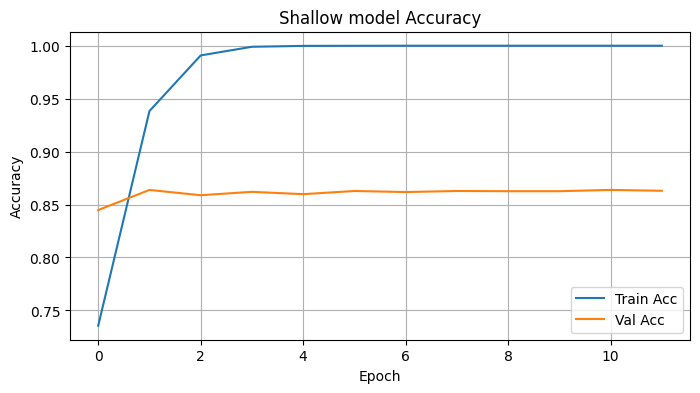

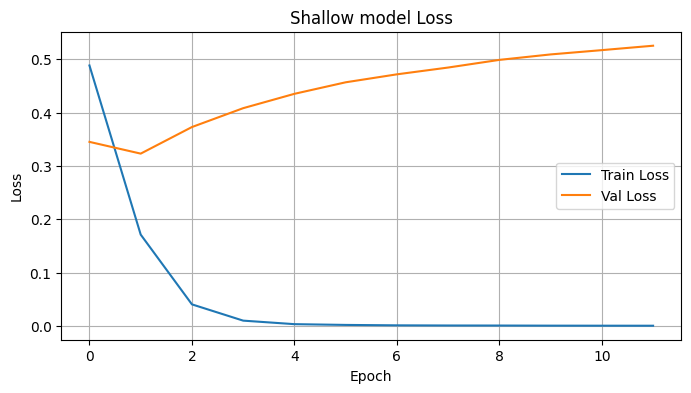

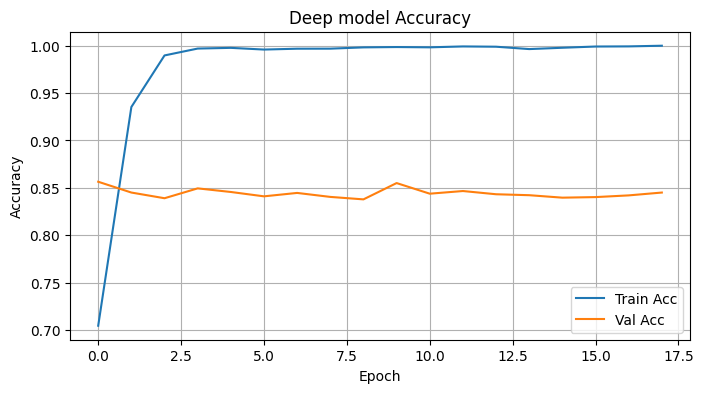

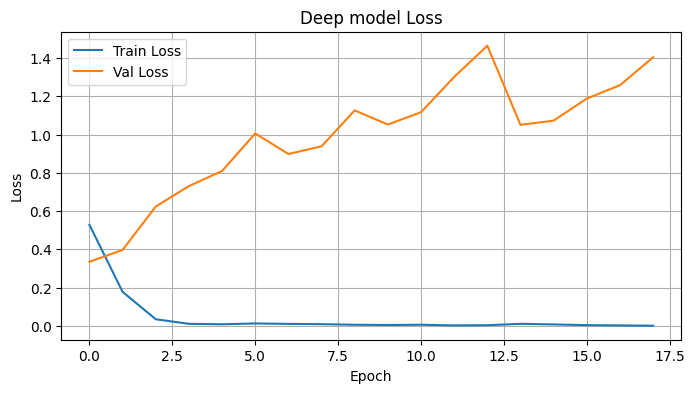


===== Summary comparison =====
Shallow model: Test Acc = 0.8633
Deep model   : Test Acc = 0.8388
Shallow overfitting gap (train - val acc, last epoch): 0.1370
Deep overfitting gap    (train - val acc, last epoch): 0.1549


In [ ]:
num_words = 10000
maxlen = 300

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

n_train = int(0.80 * len(x_train))
x_train_part = x_train[:n_train]
y_train_part = y_train[:n_train]
x_val = x_train[n_train:]
y_val = y_train[n_train:]

def build_shallow_model():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=64, input_length=maxlen),
        Flatten(),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.build(input_shape=(None, maxlen))

    model.compile(
        optimizer=Adam(),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

shallow_model = build_shallow_model()
shallow_model.summary()

epochs_shallow = 12
history_shallow = shallow_model.fit(
    x_train_part,
    y_train_part,
    epochs=epochs_shallow,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

test_loss_shallow, test_acc_shallow = shallow_model.evaluate(x_test, y_test, verbose=0)
print(f"[Shallow] Test Loss: {test_loss_shallow:.4f} | Test Accuracy: {test_acc_shallow:.4f}")

y_prob_shallow = shallow_model.predict(x_test, verbose=0).ravel()
y_pred_shallow = (y_prob_shallow >= 0.5).astype(int)
cm_shallow = confusion_matrix(y_test, y_pred_shallow)
print("[Shallow] Confusion matrix:\n", cm_shallow)
print("[Shallow] Classification report:\n", classification_report(y_test, y_pred_shallow))

def build_deep_model():
    model = Sequential([
        Embedding(input_dim=num_words, output_dim=64, input_length=maxlen),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.build(input_shape=(None, maxlen))

    model.compile(
        optimizer=Adam(),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

deep_model = build_deep_model()
deep_model.summary()

epochs_deep = 18
history_deep = deep_model.fit(
    x_train_part,
    y_train_part,
    epochs=epochs_deep,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

test_loss_deep, test_acc_deep = deep_model.evaluate(x_test, y_test, verbose=0)
print(f"[Deep] Test Loss: {test_loss_deep:.4f} | Test Accuracy: {test_acc_deep:.4f}")

y_prob_deep = deep_model.predict(x_test, verbose=0).ravel()
y_pred_deep = (y_prob_deep >= 0.5).astype(int)
cm_deep = confusion_matrix(y_test, y_pred_deep)
print("[Deep] Confusion matrix:\n", cm_deep)
print("[Deep] Classification report:\n", classification_report(y_test, y_pred_deep))

def plot_history(history, title_prefix="Model"):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["accuracy"], label="Train Acc")
    plt.plot(history.history["val_accuracy"], label="Val Acc")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history_shallow, title_prefix="Shallow model")
plot_history(history_deep, title_prefix="Deep model")


print("\n===== Summary comparison =====")
print(f"Shallow model: Test Acc = {test_acc_shallow:.4f}")
print(f"Deep model   : Test Acc = {test_acc_deep:.4f}")

gap_shallow = history_shallow.history["accuracy"][-1] - history_shallow.history["val_accuracy"][-1]
gap_deep = history_deep.history["accuracy"][-1] - history_deep.history["val_accuracy"][-1]
print(f"Shallow overfitting gap (train - val acc, last epoch): {gap_shallow:.4f}")
print(f"Deep overfitting gap    (train - val acc, last epoch): {gap_deep:.4f}")

Shallow model perform well with quick training; when test accuracy better than deeper model and overfitting stays minimal, they're often favored for their efficiency.

